# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mahmoud-Beram/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

Observation: All three traffic fields (Impressions, Clicks) show extreme heavy-tail distributions. The median impressions is 173 while the mean is 1,588 (9× gap), and 50% of articles received zero clicks. This means we must use medians or bucket tables for our signal tests, never raw averages.

In [1]:
from huggingface_hub import hf_hub_download
from google.colab import userdata
import duckdb


hf_token = userdata.get('HF_TOKEN').strip()
print("Downloading file from Hugging Face... please wait.")
local_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    repo_type="dataset",
    token=hf_token
)
con = duckdb.connect()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

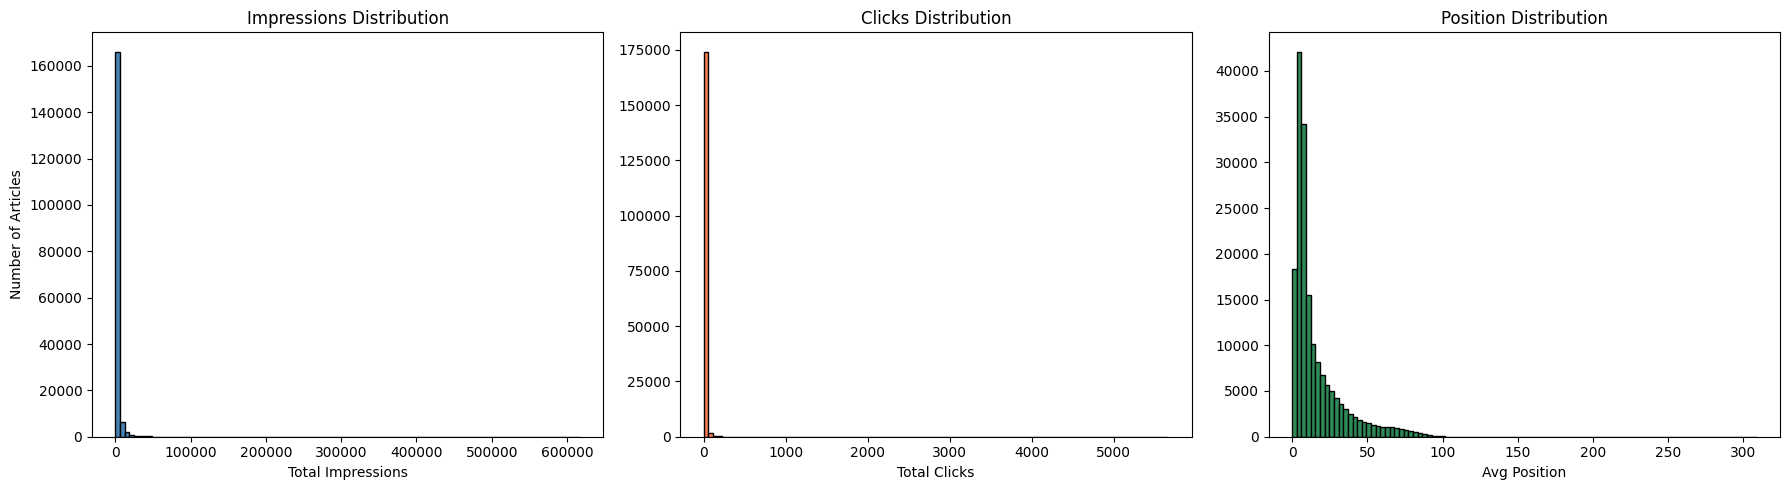


--- Key Statistics ---
       total_impressions   total_clicks   avg_position
count      176738.000000  176738.000000  176738.000000
mean         1587.986675       4.650002      15.999277
std          5431.337724      26.722649      17.686260
min             1.000000       0.000000       0.000000
25%            20.000000       0.000000       5.001970
50%           173.000000       0.000000       8.505296
75%          1039.000000       2.000000      20.369190
max        617124.000000    5668.000000     309.000000


In [2]:
import matplotlib.pyplot as plt

stats_df = con.execute(f"""
    SELECT
        content_hash_id,
        SUM(gsc_impressions) as total_impressions,
        SUM(gsc_clicks) as total_clicks,
        AVG(gsc_avg_position) as avg_position
    FROM '{local_file}'
    GROUP BY content_hash_id
    HAVING total_impressions > 0
""").df()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Impressions
axes[0].hist(stats_df['total_impressions'], bins=100, color='steelblue', edgecolor='black')
axes[0].set_title('Impressions Distribution')
axes[0].set_xlabel('Total Impressions')
axes[0].set_ylabel('Number of Articles')

# 2. Clicks
axes[1].hist(stats_df['total_clicks'], bins=100, color='coral', edgecolor='black')
axes[1].set_title('Clicks Distribution')
axes[1].set_xlabel('Total Clicks')

# 3. Position
axes[2].hist(stats_df['avg_position'], bins=100, color='seagreen', edgecolor='black')
axes[2].set_title('Position Distribution')
axes[2].set_xlabel('Avg Position')

plt.tight_layout()
plt.show()


print("\n--- Key Statistics ---")
print(stats_df[['total_impressions', 'total_clicks', 'avg_position']].describe())



## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

Signal 1 (Position → CTR): Claim: Pages on Page 1 get higher CTR. Verdict: CONFIRMED. Page 1 CTR (0.62%) is 4× Buried pages (0.15%).

Signal 2 (Impressions → Clicks share): Claim: High-impression articles drive most clicks. Verdict: CONFIRMED. High + Viral articles (25% of articles) drive 93% of all clicks.

Signal 3 (AI Traffic → Google Clicks): Claim: Articles referenced by AI tools also get more Google clicks. Verdict: CONFIRMED. Even after controlling for impression tier, AI-traffic articles get 2× the median clicks (13 vs 6, n=2,676).

In [3]:
# 1. Signal 1 Test: Position vs CTR (Confirmed before)
print("--- Signal 1: CTR vs Position Page ---")
signal1_df = con.execute(f"""
    WITH article_stats AS (
        SELECT content_hash_id, SUM(gsc_impressions) as total_imp, SUM(gsc_clicks) as total_clicks, AVG(gsc_avg_position) as avg_pos
        FROM '{local_file}' GROUP BY content_hash_id HAVING total_imp > 0
    )
    SELECT
        CASE
            WHEN avg_pos <= 10 THEN 'Page 1 (Pos 1-10)'
            WHEN avg_pos <= 20 THEN 'Page 2 (Pos 11-20)'
            WHEN avg_pos <= 30 THEN 'Page 3 (Pos 21-30)'
            ELSE 'Buried (Page 4+)'
        END AS position_bucket,
        COUNT(content_hash_id) AS n_articles,
        AVG(total_clicks / total_imp) * 100 AS avg_ctr_percentage
    FROM article_stats GROUP BY position_bucket ORDER BY avg_ctr_percentage DESC
""").df()
display(signal1_df)


# 2. Signal 2 Test: Impressions Volume vs Clicks (Confirmed before)
print("\n--- Signal 2: Impressions Volume vs Total Clicks ---")
signal2_df = con.execute(f"""
    WITH article_stats AS (
        SELECT content_hash_id, SUM(gsc_impressions) as total_imp, SUM(gsc_clicks) as total_clicks
        FROM '{local_file}' GROUP BY content_hash_id HAVING total_imp > 0
    )
    SELECT
        CASE
            WHEN total_imp < 100 THEN '1. Low (< 100)'
            WHEN total_imp < 1000 THEN '2. Medium (100 - 1K)'
            WHEN total_imp < 10000 THEN '3. High (1K - 10K)'
            ELSE '4. Viral (> 10K)'
        END AS volume_bucket,
        COUNT(content_hash_id) AS n_articles,
        SUM(total_clicks) AS bucket_total_clicks
    FROM article_stats GROUP BY volume_bucket ORDER BY volume_bucket ASC
""").df()
display(signal2_df)


# 3. Signal 3 Test: AI Traffic vs Google Clicks
print("\n--- Signal 3: AI Traffic vs Median Google Clicks ---")
signal3_df = con.execute(f"""
    WITH article_stats AS (
        SELECT
            content_hash_id,
            SUM(gsc_clicks) as total_google_clicks,
            SUM(sessions_ai) as total_ai_traffic
        FROM '{local_file}'
        GROUP BY content_hash_id
    )
    SELECT
        CASE
            WHEN total_ai_traffic IS NULL OR total_ai_traffic = 0 THEN '0. No AI Traffic'
            WHEN total_ai_traffic < 10 THEN '1. Low AI (< 10)'
            ELSE '2. High AI (>= 10)'
        END AS ai_bucket,
        COUNT(content_hash_id) AS n_articles,
        MEDIAN(total_google_clicks) AS median_google_clicks
    FROM article_stats
    GROUP BY ai_bucket
    ORDER BY ai_bucket ASC
""").df()
display(signal3_df)


--- Signal 1: CTR vs Position Page ---


,position_bucket,n_articles,avg_ctr_percentage
0,Page 1 (Pos 1-10),99566,0.624545
1,Page 2 (Pos 11-20),32203,0.321119
2,Page 3 (Pos 21-30),17173,0.254824
3,Buried (Page 4+),27796,0.154422



--- Signal 2: Impressions Volume vs Total Clicks ---


,volume_bucket,n_articles,bucket_total_clicks
0,1. Low (< 100),75297,6457.0
1,2. Medium (100 - 1K),56383,53028.0
2,3. High (1K - 10K),39181,384511.0
3,4. Viral (> 10K),5877,377836.0



--- Signal 3: AI Traffic vs Median Google Clicks ---


,ai_bucket,n_articles,median_google_clicks
0,0. No AI Traffic,327642,0.0
1,1. Low AI (< 10),3714,6.0
2,2. High AI (>= 10),81,20.0


In [4]:

print("--- Verification: AI Traffic effect WITHIN same impression tier ---")
verify_df = con.execute(f"""
    WITH article_stats AS (
        SELECT
            content_hash_id,
            SUM(gsc_impressions) as total_imp,
            SUM(gsc_clicks) as total_clicks,
            SUM(sessions_ai) as total_ai
        FROM '{local_file}'
        GROUP BY content_hash_id
        HAVING total_imp > 0
    )
    SELECT
        CASE
            WHEN total_imp < 1000 THEN 'Low Impressions'
            ELSE 'High Impressions'
        END AS imp_tier,

        CASE
            WHEN total_ai IS NULL OR total_ai = 0 THEN 'No AI'
            ELSE 'Has AI'
        END AS ai_status,

        COUNT(*) AS n,
        MEDIAN(total_clicks) AS median_clicks

    FROM article_stats
    GROUP BY imp_tier, ai_status
    ORDER BY imp_tier, ai_status
""").df()

display(verify_df)


--- Verification: AI Traffic effect WITHIN same impression tier ---


,imp_tier,ai_status,n,median_clicks
0,High Impressions,Has AI,2676,13.0
1,High Impressions,No AI,42382,6.0
2,Low Impressions,Has AI,838,0.0
3,Low Impressions,No AI,130842,0.0


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

Flag-Linked Test: Quick-Win Flag Claim: Articles at positions 11-15 (top of Page 2) would gain significantly more clicks if pushed to Page 1. Verdict: MIXED. There is a directional CTR improvement from Page 2 to Page 1 (0.33% → 0.41%), but the absolute gap is modest, median clicks are zero across all zones, and we only have one month of data to test on. The flag's logic is reasonable but not strongly confirmed by this single slice.

In [5]:
# Section 3: Quick-Win Flag Test
print("--- Flag-Linked Test: Quick-Win (Page 2 → Page 1 jump) ---")
quickwin_df = con.execute(f"""
    WITH article_stats AS (
        SELECT
            content_hash_id,
            SUM(gsc_impressions) as total_imp,
            SUM(gsc_clicks) as total_clicks,
            AVG(gsc_avg_position) as avg_pos
        FROM '{local_file}'
        GROUP BY content_hash_id
        HAVING total_imp > 0
    )
    SELECT
        CASE
            WHEN avg_pos BETWEEN 6 AND 10 THEN '1. Bottom Page 1 (6-10)'
            WHEN avg_pos BETWEEN 11 AND 15 THEN '2. Top Page 2 (11-15) ← Quick Wins'
            WHEN avg_pos BETWEEN 16 AND 20 THEN '3. Mid Page 2 (16-20)'
        END AS position_zone,
        COUNT(*) AS n,
        MEDIAN(total_clicks) AS median_clicks,
        AVG(total_clicks / total_imp) * 100 AS avg_ctr_pct
    FROM article_stats
    WHERE avg_pos BETWEEN 6 AND 20
    GROUP BY position_zone
    ORDER BY position_zone
""").df()

display(quickwin_df)


--- Flag-Linked Test: Quick-Win (Page 2 → Page 1 jump) ---


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,position_zone,n,median_clicks,avg_ctr_pct
0,1. Bottom Page 1 (6-10),42565,0.0,0.408516
1,2. Top Page 2 (11-15) ← Quick Wins,14735,0.0,0.329108
2,3. Mid Page 2 (16-20),9933,0.0,0.323614
3,None,7535,0.0,0.302207


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*


First, prioritize by volume: 93% of all site clicks come from just 25% of articles (the High and Viral tiers). The content team should focus review efforts on high-impression articles rather than spreading thin across every page.

Second, among those high-impression articles, fix the ones on Page 1 with abnormally low CTR first — these are the biggest missed opportunities because small title/snippet improvements can unlock thousands of clicks.

Third, AI-referenced articles show 2× the median clicks even within the same impression tier (n=2,676). Monitoring which content AI tools cite — and ensuring those pages are well-maintained — is an emerging but data-supported priority.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.